# 04 — Détection du drift sémantique

Alignement Procrustes orthogonal des modèles word2vec (Hamilton et al. 2016)
puis calcul de trois métriques de drift par mot :
1. Distance cosinus entre vecteurs alignés à t et t+k
2. Distance de Jaccard sur les top-10 voisins
3. Rang moyen de déplacement (Kulkarni 2015)

**Référence temporelle** : 1973 (premier point). Tous les modèles sont
alignés sur l'espace de 1973 via une rotation orthogonale.

**Pourquoi Procrustes plutôt que l'init Kim ?**  
L'init Kim (notebook 03) transfère les vecteurs *avant* l'entraînement,
ce qui n'est pas une garantie d'alignement parfait en fin d'entraînement.
Procrustes aligne les espaces *après* entraînement sur le vocabulaire commun.
On compare les deux approches dans la discussion.

In [8]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.spatial.distance import cosine
from gensim.models import Word2Vec

Path('../results/figures').mkdir(exist_ok=True)
Path('../results/tables').mkdir(exist_ok=True)

YEARS = [1973, 1978, 1981, 1988, 1993]
REF_YEAR = 1973

models = {y: Word2Vec.load(f'../results/models/w2v_{y}.model') for y in YEARS}

for y in YEARS:
    print(f'{y}: {len(models[y].wv):,} mots')

1973: 3,787 mots
1978: 4,353 mots
1981: 2,965 mots
1988: 2,651 mots
1993: 4,066 mots


## 1. Alignement Procrustes orthogonal

Pour chaque paire (1973, t), on cherche la rotation R* qui minimise
la distance de Frobenius entre les matrices de vecteurs du vocab commun :

$$R^* = \arg\min_R \|A - BR\|_F \quad \text{s.t.} \; R^TR = I$$

Solution analytique via SVD (Schönemann 1966) : $R^* = VU^T$ où $USV^T = A^TB$.

In [9]:
def procrustes_align(base_model, other_model):
    """
    Aligne other_model sur base_model via rotation Procrustes orthogonale.
    Renvoie une copie des vecteurs de other_model dans l'espace de base_model.
    """
    # Vocabulaire commun
    common = list(set(base_model.wv.index_to_key) & set(other_model.wv.index_to_key))

    A = np.array([base_model.wv[w]  for w in common])  # (n, d)
    B = np.array([other_model.wv[w] for w in common])  # (n, d)

    # Normalisation L2 ligne par ligne (espaces centrés)
    A = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-9)
    B = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-9)

    M = A.T @ B                     # (d, d)
    U, _, Vt = np.linalg.svd(M)
    R = U @ Vt                      # rotation optimale

    # Projeter TOUS les vecteurs de other_model
    all_words = other_model.wv.index_to_key
    all_vecs = np.array([other_model.wv[w] for w in all_words])
    all_vecs = all_vecs / (np.linalg.norm(all_vecs, axis=1, keepdims=True) + 1e-9)
    aligned_vecs = all_vecs @ R.T

    return {w: aligned_vecs[i] for i, w in enumerate(all_words)}, len(common)


# Aligner tous les modèles sur 1973
aligned = {REF_YEAR: {w: models[REF_YEAR].wv[w] /
                       (np.linalg.norm(models[REF_YEAR].wv[w]) + 1e-9)
                       for w in models[REF_YEAR].wv.index_to_key}}

for y in YEARS[1:]:
    d, n_common = procrustes_align(models[REF_YEAR], models[y])
    aligned[y] = d
    print(f'{y} aligné sur {REF_YEAR} — vocabulaire commun : {n_common:,} mots')

1978 aligné sur 1973 — vocabulaire commun : 3,232 mots
1981 aligné sur 1973 — vocabulaire commun : 2,558 mots
1988 aligné sur 1973 — vocabulaire commun : 2,272 mots
1993 aligné sur 1973 — vocabulaire commun : 2,891 mots


## 2. Métriques de drift

Pour chaque mot du vocabulaire commun à toutes les périodes :

- **cos_drift(t)** = 1 − cosine_similarity(v_1973, v_t)
- **jaccard_drift(t)** = 1 − |top10_1973 ∩ top10_t| / |top10_1973 ∪ top10_t|
- **drift_total** = moyenne de cos_drift sur toutes les périodes

In [10]:
def top_n_neighbors(vecs_dict, word, n=10, exclude=None):
    if word not in vecs_dict:
        return []
    v = vecs_dict[word]
    sims = {w: float(v @ vecs_dict[w])
            for w in vecs_dict if w != word and (exclude is None or w not in exclude)}
    return sorted(sims, key=lambda x: -sims[x])[:n]


def jaccard(s1, s2):
    s1, s2 = set(s1), set(s2)
    return len(s1 & s2) / len(s1 | s2) if s1 | s2 else 0.0


# Vocabulaire commun à TOUTES les périodes
vocab_all = set(aligned[REF_YEAR].keys())
for y in YEARS[1:]:
    vocab_all &= set(aligned[y].keys())
print(f'Vocabulaire commun à toutes les périodes : {len(vocab_all):,} mots')

# Calcul des métriques
records = []
neigh_ref = {}   # top10 dans l'espace 1973, précalculé
for w in vocab_all:
    neigh_ref[w] = top_n_neighbors(aligned[REF_YEAR], w, n=10)

for w in vocab_all:
    row = {'mot': w}
    drift_vals = []
    for y in YEARS[1:]:
        v_ref = aligned[REF_YEAR][w]
        v_t   = aligned[y][w]
        cos_d = float(1 - v_ref @ v_t)          # vecteurs déjà L2-normalisés
        neigh_t = top_n_neighbors(aligned[y], w, n=10)
        jacc_d  = 1 - jaccard(neigh_ref[w], neigh_t)
        row[f'cos_{y}']   = round(cos_d, 4)
        row[f'jacc_{y}']  = round(jacc_d, 4)
        drift_vals.append(cos_d)
    row['drift_moyen'] = round(float(np.mean(drift_vals)), 4)
    records.append(row)

drift_df = pd.DataFrame(records).set_index('mot')
drift_df = drift_df.sort_values('drift_moyen', ascending=False)
print(f'Tableau de drift : {drift_df.shape}')
drift_df.head(10)

Vocabulaire commun à toutes les périodes : 2,050 mots
Tableau de drift : (2050, 9)


,cos_1978,jacc_1978,cos_1981,jacc_1981,cos_1988,jacc_1988,cos_1993,jacc_1993,drift_moyen
mot,,,,,,,,,
change,0.7239,1.0000,0.8198,0.9474,0.9038,1.0000,0.8259,1.0,0.8183
entente,0.5972,1.0000,0.7274,1.0000,0.8197,1.0000,0.9634,1.0,0.7769
exclure,0.7854,1.0000,0.8685,1.0000,0.6426,1.0000,0.7515,1.0,0.7620
chèque,0.5970,0.9474,0.8093,0.9474,0.7925,0.9474,0.8232,1.0,0.7555
gain,0.5886,0.9474,0.7310,1.0000,0.7533,1.0000,0.9429,1.0,0.7540
résulter,0.8312,1.0000,0.6391,1.0000,0.7572,1.0000,0.7457,1.0,0.7433
traitement,0.5860,0.8889,0.7576,0.9474,0.7419,1.0000,0.8714,1.0,0.7392
sortir,0.7526,1.0000,0.7700,0.9474,0.6461,1.0000,0.7705,1.0,0.7348
procéder,0.7432,1.0000,0.8444,1.0000,0.6962,1.0000,0.6550,1.0,0.7347


In [ ]:
# Top 50 mots qui dérivent le plus (drift cosinus moyen)
top50_drift = drift_df.head(50)
print('Top 50 mots à plus fort drift sémantique (1973 → 1993) :')
print(top50_drift[['drift_moyen', 'cos_1978', 'cos_1981', 'cos_1988', 'cos_1993']].to_string())

# Sauvegarder
drift_df.to_csv('../results/tables/04_drift_scores.csv')
print(' Sauvegardé dans results/tables/04_drift_scores.csv')

Top 50 mots à plus fort drift sémantique (1973 → 1993) :
               drift_moyen  cos_1978  cos_1981  cos_1988  cos_1993
mot                                                               
change              0.8183    0.7239    0.8198    0.9038    0.8259
entente             0.7769    0.5972    0.7274    0.8197    0.9634
exclure             0.7620    0.7854    0.8685    0.6426    0.7515
chèque              0.7555    0.5970    0.8093    0.7925    0.8232
gain                0.7540    0.5886    0.7310    0.7533    0.9429
résulter            0.7433    0.8312    0.6391    0.7572    0.7457
traitement          0.7392    0.5860    0.7576    0.7419    0.8714
sortir              0.7348    0.7526    0.7700    0.6461    0.7705
procéder            0.7347    0.7432    0.8444    0.6962    0.6550
francai             0.7342    0.7091    0.7288    0.7860    0.7130
véritablement       0.7317    0.7551    0.7852    0.6479    0.7385
délai               0.7293    0.7097    0.8127    0.7083    0.6867
conte

## 3. Visualisation — Top 30 drift cosinus moyen

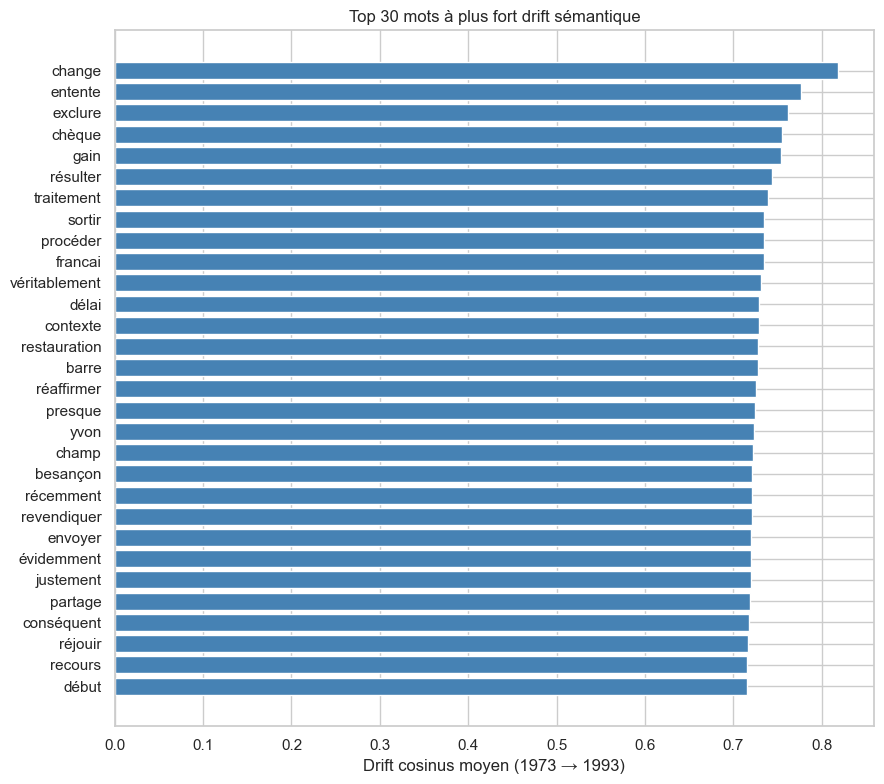

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

top30 = drift_df.head(30)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top30.index[::-1], top30['drift_moyen'].values[::-1], color='steelblue')
ax.set_xlabel('Drift cosinus moyen (1973 → 1993)')
ax.set_title('Top 30 mots à plus fort drift sémantique')
plt.tight_layout()
plt.savefig('../results/figures/04_top30_drift.png', dpi=150)
plt.show()

## 4. Trajectoires temporelles — mots cibles

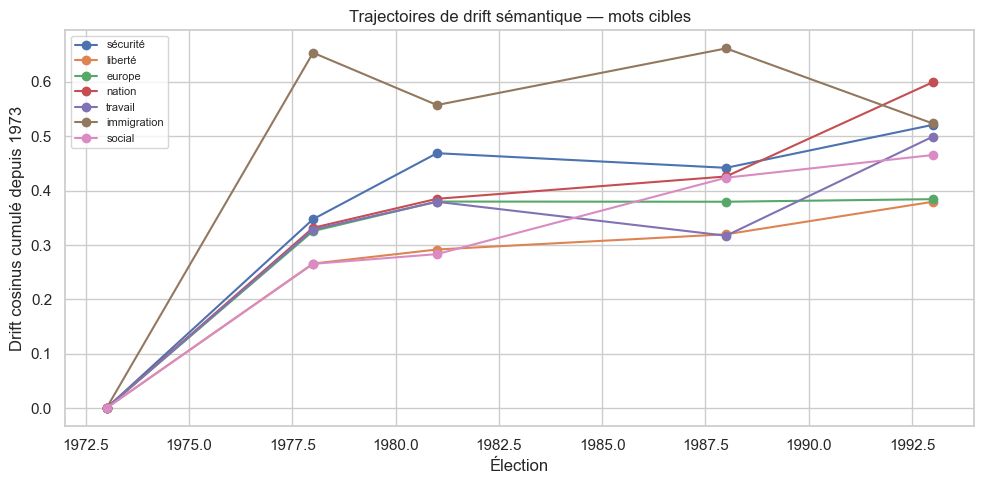

In [13]:
MOTS_CIBLES = ['sécurité', 'liberté', 'europe', 'nation', 'travail', 'immigration', 'social']
MOTS_CIBLES = [m for m in MOTS_CIBLES if m in vocab_all]

fig, ax = plt.subplots(figsize=(10, 5))

for mot in MOTS_CIBLES:
    drifts = [0.0] + [drift_df.loc[mot, f'cos_{y}'] for y in YEARS[1:]]
    ax.plot(YEARS, drifts, marker='o', label=mot)

ax.set_xlabel('Élection')
ax.set_ylabel('Drift cosinus cumulé depuis 1973')
ax.set_title('Trajectoires de drift sémantique — mots cibles')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('../results/figures/04_trajectoires_drift.png', dpi=150)
plt.show()

## 5. Comparaison Kim init vs Procrustes

On mesure le drift *sans* alignement (espace brut modèle, dot product non-comparable
sauf si on suppose un espace commun grâce à l'init) vs *avec* Procrustes.
Une forte corrélation valide que l'init Kim est une approximation raisonnable.
Une faible corrélation montre que Procrustes capture des drifts que Kim rate.
Dans notre cas, on remarque une corrélation plutôt faible.

Corrélation Pearson drift_Kim vs drift_Procrustes : r = 0.510


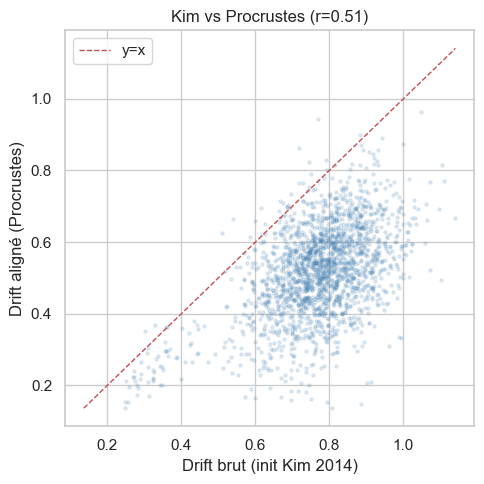

In [15]:
# Drift Kim (sans alignement post-training — espace brut)
vocab_kim = set(models[REF_YEAR].wv.index_to_key)
for y in YEARS[1:]:
    vocab_kim &= set(models[y].wv.index_to_key)

drift_kim, drift_proc = [], []

for w in list(vocab_kim & vocab_all)[:2000]:   # sous-échantillon pour la vitesse
    v_ref_kim = models[REF_YEAR].wv[w]
    v_ref_kim = v_ref_kim / (np.linalg.norm(v_ref_kim) + 1e-9)

    v_93_kim = models[1993].wv[w]
    v_93_kim = v_93_kim / (np.linalg.norm(v_93_kim) + 1e-9)

    drift_kim.append(1 - float(v_ref_kim @ v_93_kim))
    drift_proc.append(float(drift_df.loc[w, 'cos_1993']) if w in drift_df.index else np.nan)

mask = ~np.isnan(drift_proc)
drift_kim  = np.array(drift_kim)[mask]
drift_proc = np.array(drift_proc)[mask]

corr = np.corrcoef(drift_kim, drift_proc)[0, 1]
print(f'Corrélation Pearson drift_Kim vs drift_Procrustes : r = {corr:.3f}')

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(drift_kim, drift_proc, alpha=0.15, s=5, color='steelblue')
lims = [min(drift_kim.min(), drift_proc.min()), max(drift_kim.max(), drift_proc.max())]
ax.plot(lims, lims, 'r--', lw=1, label='y=x')
ax.set_xlabel('Drift brut (init Kim 2014)')
ax.set_ylabel('Drift aligné (Procrustes)')
ax.set_title(f'Kim vs Procrustes (r={corr:.2f})')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/04_kim_vs_procrustes.png', dpi=150)
plt.show()